Project Objective

The objective of this project is to analyze customer purchasing behavior using RFM (Recency, Frequency, Monetary) analysis. By segmenting customers based on their purchasing patterns, the business can identify high-value customers, improve retention strategies, and support data-driven marketing decisions.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from datetime import timedelta

In [46]:
df_cust = pd.read_csv(r"C:\Users\Bhupe\Downloads\Customer_Master_Data.csv")
df_txn = pd.read_csv(r"C:\Users\Bhupe\Downloads\Customer_Transactions.csv")

In [47]:
df_cust.head(10)

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04
5,CUST10005,Fateh Sharaf,qkulkarni@gmail.com,Male,59,Jaipur,Single,3,2021-05-13
6,CUST10006,Khushi Wadhwa,craja@yahoo.com,Female,61,Hyderabad,Widowed,2,2021-11-12
7,CUST10007,Zeeshan Salvi,ira51@saini-kumar.com,Not Disclosed,32,Pune,Widowed,1,2021-08-10
8,CUST10008,Elakshi Trivedi,ayesha07@gmail.com,Female,32,Hyderabad,Widowed,4,2023-11-20
9,CUST10009,Neelofar Chada,abramsolanki@madan.com,Male,44,Jaipur,Single,0,2021-11-20


In [48]:
df_txn.head(10)

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,7/31/23,2383.07
1,CUST10100,3/10/24,497.54
2,CUST10031,2/17/25,536.78
3,CUST10987,7/17/23,314.89
4,CUST10831,12/15/24,2543.19
5,CUST10404,2/28/25,432.22
6,CUST10488,6/7/25,2178.25
7,CUST10988,3/25/25,85.46
8,CUST10657,9/10/23,1800.32
9,CUST10007,12/15/23,305.90


In [49]:
cust_shape = df_cust.shape

print("Total no. of Customer are :",cust_shape[0])

Total no. of Customer are : 1000


In [50]:
txn_shape = df_txn.shape

print("Total no. of Transactions are :",txn_shape[0])


Total no. of Transactions are : 23050


Data Quality

In [51]:
#1. Missing Values

missing_values_cust = df_cust.isnull().sum()  

print("Missing values in Customer dataset :")
print(missing_values_cust)


Missing values in Customer dataset :
CustomerID       0
Name             0
Email            0
Gender           0
Age              0
City             0
MaritalStatus    0
NumChildren      0
JoinDate         0
dtype: int64


In [52]:
missing_values_txn = df_txn.isnull().sum()

print("Missing values in Transactions dataset :")
print(missing_values_txn)

Missing values in Transactions dataset :
CustomerID           0
TransactionDate      0
TransactionAmount    0
dtype: int64


In [53]:
#2. Data Types

df_cust.dtypes

CustomerID       object
Name             object
Email            object
Gender           object
Age               int64
City             object
MaritalStatus    object
NumChildren       int64
JoinDate         object
dtype: object

In [54]:
df_txn.dtypes

CustomerID            object
TransactionDate       object
TransactionAmount    float64
dtype: object

In [55]:
df_cust['JoinDate'] = pd.to_datetime(df_cust['JoinDate'])        # Converting Date columns in DateTime format

In [56]:
df_txn['TransactionDate'] = pd.to_datetime(df_txn['TransactionDate'])      # Converting Date columns in DateTime format

C:\Users\Bhupe\AppData\Local\Temp\ipykernel_8656\500869026.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_txn['TransactionDate'] = pd.to_datetime(df_txn['TransactionDate'])      # Converting Date columns in DateTime format


In [57]:
df_txn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         23050 non-null  object        
 1   TransactionDate    23050 non-null  datetime64[ns]
 2   TransactionAmount  23050 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 540.4+ KB


In [58]:
df_cust["Gender"].value_counts()

Gender
Female           340
Male             332
Not Disclosed    328
Name: count, dtype: int64

In [59]:
#3) Duplicate Records

duplicate_cust = df_cust.duplicated().sum()

print("Duplicate in Customer dataset :", duplicate_cust)

Duplicate in Customer dataset : 0


In [60]:
duplicate_txn = df_txn.duplicated().sum()

print("Duplicate in Transaction dataset :", duplicate_txn)

Duplicate in Transaction dataset : 0


In [61]:
#4) Customer ID Validation

df_cust["CustomerID"].nunique()

1000

In [62]:
df_txn["CustomerID"].nunique()

1000

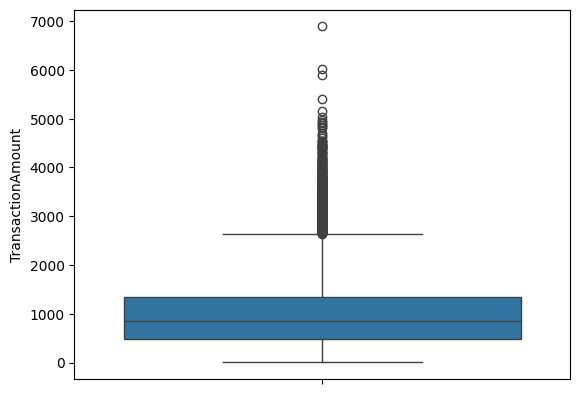

In [63]:
#5) Outlier Detection

sns.boxplot(data=df_txn,y="TransactionAmount")
plt.show()

In [64]:
# Valid Transaction whose CustomerID exists in master Customer data

df_txn = df_txn.loc[df_txn["CustomerID"].isin(df_cust["CustomerID"])].copy()

"The purpose of RFM analysis is to segment customers based on purchase recency, purchase frequency, and total spending. This helps identify high-value customers and supports targeted marketing strategies."

# RFM Calculation


In [65]:
ref_date = df_txn['TransactionDate'].max() + timedelta(days=1) 

In [66]:
print(ref_date)

2025-07-30 00:00:00


In [67]:
rfm = df_txn.groupby('CustomerID').agg({
    'TransactionDate': lambda x: (ref_date - x.max()).days,
    'CustomerID': 'count',
    'TransactionAmount': 'sum'
})

In [68]:
rfm.head()

,TransactionDate,CustomerID,TransactionAmount
CustomerID,,,
CUST10000,13,23,21265.49
CUST10001,35,30,28654.31
CUST10002,18,24,23884.03
CUST10003,81,25,24206.03
CUST10004,8,19,25565.30


In [69]:
rfm.columns = ['Recency' , 'Frequency' , 'Monetary']
rfm.reset_index(inplace = True)

In [70]:
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,CUST10000,13,23,21265.49
1,CUST10001,35,30,28654.31
2,CUST10002,18,24,23884.03
3,CUST10003,81,25,24206.03
4,CUST10004,8,19,25565.30
5,CUST10005,24,29,29459.82
6,CUST10006,11,28,27922.36
7,CUST10007,86,15,14957.06
8,CUST10008,3,19,19479.25
9,CUST10009,7,25,22832.83


In [71]:
rfm.shape

(1000, 4)

# RFM Scoring 

In [72]:
rfm['R_Score'] = pd.qcut(rfm['Recency'],q=5,labels=[5,4,3,2,1])   # Recency (lower is better)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),q=5,labels=[1,2,3,4,5])     # Frequency (higher is better)
rfm['M_Score'] = pd.qcut(rfm['Monetary'],q=5, labels= [1,2,3,4,5])     # Monetary (higher is better)

In [73]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,CUST10000,13,23,21265.49,4,3,2
1,CUST10001,35,30,28654.31,3,5,5
2,CUST10002,18,24,23884.03,4,3,3
3,CUST10003,81,25,24206.03,1,4,3
4,CUST10004,8,19,25565.30,5,1,4


In [74]:
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + \
                     rfm['F_Score'].astype(str) + \
                     rfm['M_Score'].astype(str) 

In [75]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment
0,CUST10000,13,23,21265.49,4,3,2,432
1,CUST10001,35,30,28654.31,3,5,5,355
2,CUST10002,18,24,23884.03,4,3,3,433
3,CUST10003,81,25,24206.03,1,4,3,143
4,CUST10004,8,19,25565.30,5,1,4,514


In [76]:
def segment(row):
    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    if (r>=4) and (f>=4) and (m>=4):
        return 'Champions'
    
    elif (f>= 4) and (r>= 2):
        return 'Loyal'
    
    elif (r>= 4) and (2<=f<=3):
        return 'Potential Loyalist'
    
    elif (r<= 2) and (f>=3):
        return 'At Risk'
    
    elif (m>=4) and (2<=f<=3) and (r>=3):
        return 'Big Spenders'
    
    elif (r== 1) and (f<=2) and (m<=2):
        return 'Lost'
    
    else:
        return 'Others'
    
rfm['Segment'] = rfm.apply(segment, axis=1)

In [77]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,Segment
0,CUST10000,13,23,21265.49,4,3,2,432,Potential Loyalist
1,CUST10001,35,30,28654.31,3,5,5,355,Loyal
2,CUST10002,18,24,23884.03,4,3,3,433,Potential Loyalist
3,CUST10003,81,25,24206.03,1,4,3,143,At Risk
4,CUST10004,8,19,25565.30,5,1,4,514,Others


In [78]:
rfm['Segment'].value_counts()

Segment
Others                260
Loyal                 206
Potential Loyalist    167
At Risk               146
Champions             131
Lost                   73
Big Spenders           17
Name: count, dtype: int64

In [79]:
print("\n=============== SIMPLE BUSINESS ANALYSIS==============")

print("\nOverall Business Summary")
total_customers = rfm["CustomerID"].shape[0]
print("The total numbers of customers are :",total_customers)

total_revenue = rfm["Monetary"].sum()
print("Total revenue is :","Rs.",total_revenue)

avg_revenue_per_cust = rfm["Monetary"].mean()
print("Average revenue per customers are :","Rs.",round(avg_revenue_per_cust,2))

print("\n======================================================")
print("\nSegment Wise Summary")

segment_cust = rfm["Segment"].value_counts()

print("\nNumber of Customers in each segment")
print(segment_cust)

print("\n======================================================")
print("\n Revenue from each Segments")

segment_rev = rfm.groupby("Segment")["Monetary"].sum().reset_index()

print("Revenue contribution by each segment :")
print(segment_rev)


=============== SIMPLE BUSINESS ANALYSIS==============

Overall Business Summary
The total numbers of customers are : 1000
Total revenue is : Rs. 23053199.66
Average revenue per customers are : Rs. 23053.2


Segment Wise Summary

Number of Customers in each segment
Segment
Others                260
Loyal                 206
Potential Loyalist    167
At Risk               146
Champions             131
Lost                   73
Big Spenders           17
Name: count, dtype: int64


 Revenue from each Segments
Revenue contribution by each segment :
              Segment    Monetary
0             At Risk  3599943.30
1        Big Spenders   451116.15
2           Champions  3830648.66
3                Lost  1266231.98
4               Loyal  5488815.20
5              Others  4795084.59
6  Potential Loyalist  3621359.78


# Visualizations

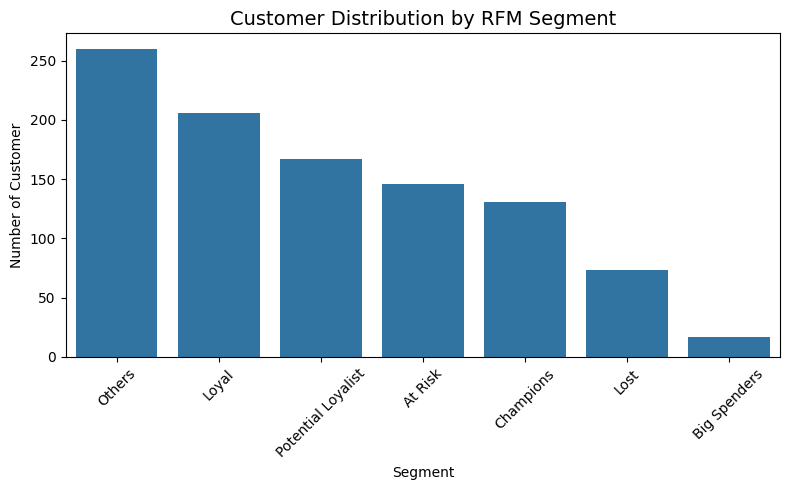


Number of Customers in each segment
Segment
Others                260
Loyal                 206
Potential Loyalist    167
At Risk               146
Champions             131
Lost                   73
Big Spenders           17
Name: count, dtype: int64


In [80]:
plt.figure(figsize=(8,5))
sns.countplot(x = 'Segment', data = rfm, order = rfm['Segment'].value_counts().index)

plt.title('Customer Distribution by RFM Segment', fontsize = 14)
plt.xlabel('Segment')
plt.ylabel('Number of Customer')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


segment_cust = rfm["Segment"].value_counts()

print("\nNumber of Customers in each segment")
print(segment_cust)


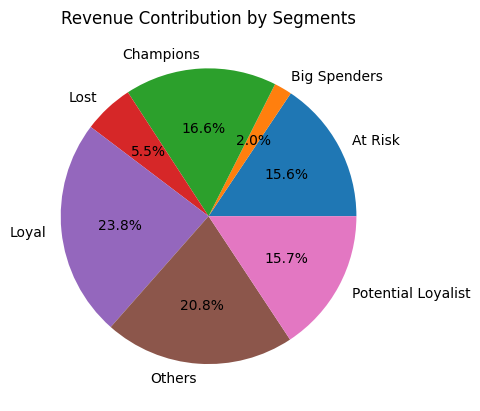

In [81]:
segment_rev = rfm.groupby("Segment")["Monetary"].sum().reset_index()

plt.Figure(figsize=(8,6))
plt.pie(segment_rev["Monetary"],labels=segment_rev["Segment"],autopct="%1.1f%%")
plt.title("Revenue Contribution by Segments")
plt.show()

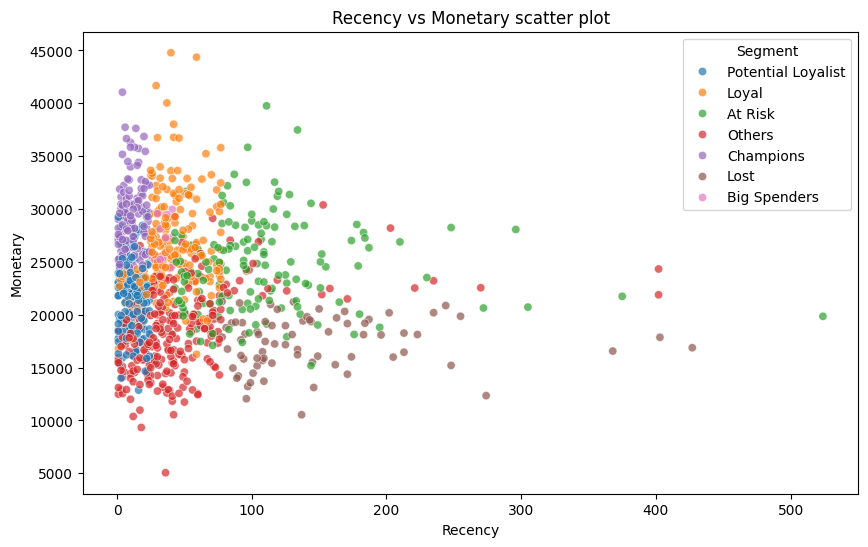

In [82]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Recency', y='Monetary', hue ='Segment', data=rfm,alpha = 0.7)
plt.title('Recency vs Monetary scatter plot')
plt.show()

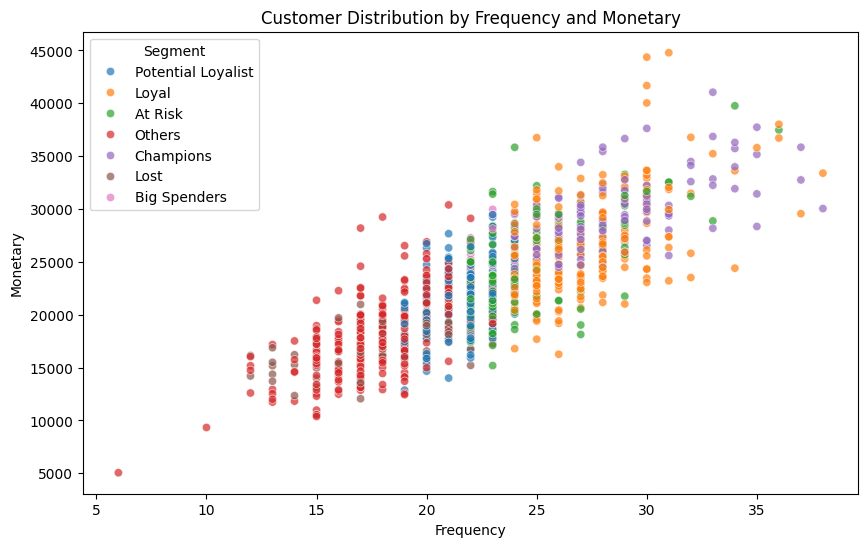

In [83]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    alpha=0.7
)

plt.title("Customer Distribution by Frequency and Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.show()

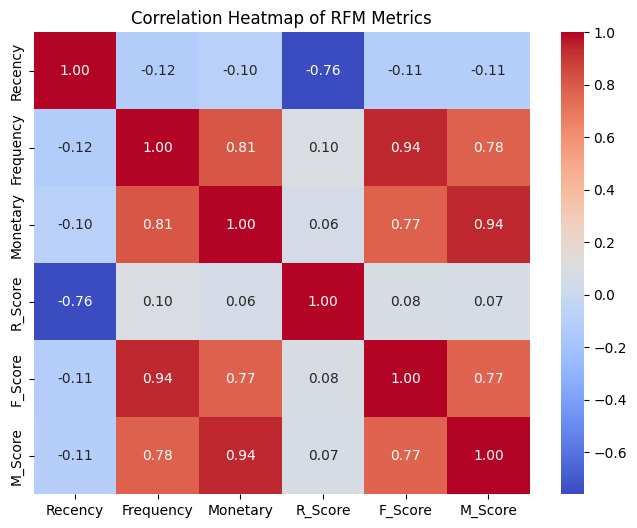

In [84]:
plt.figure(figsize=(8,6))

sns.heatmap(
    rfm[['Recency','Frequency','Monetary',
         'R_Score','F_Score','M_Score']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap of RFM Metrics")
plt.show()

Correlation Heatmap Insights
1) Frequency and Monetary show a strong positive correlation (0.81), indicating that customers who purchase more frequently generally spend more over time.

2) Frequency and F_Score (0.94) exhibit a very strong positive correlation, confirming that the Frequency score accurately reflects customer purchasing behavior.

3) Monetary and M_Score (0.94) also show a strong positive correlation, validating the effectiveness of the Monetary scoring methodology.

4) Recency and R_Score display a strong negative correlation (-0.76). This is expected because customers with fewer days since their last purchase receive higher Recency scores.

5) Recency has only weak correlations with Frequency (-0.12) and Monetary (-0.10), suggesting that recent purchasing behavior alone is not a strong predictor of spending or purchase frequency.

6) Overall, the heatmap indicates that the RFM scoring system successfully captures key aspects of customer purchasing behavior and provides a reliable basis for customer segmentation

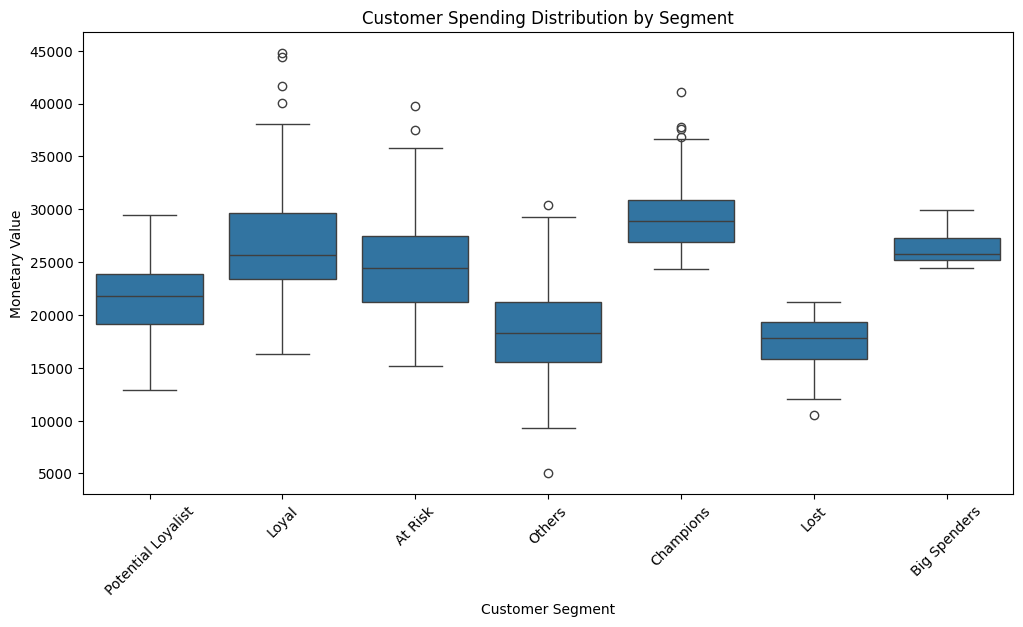

In [85]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=rfm,
    x="Segment",
    y="Monetary"
)

plt.xticks(rotation=45)
plt.title("Customer Spending Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Monetary Value")
plt.show()

Insight

The box plot highlights the distribution of customer spending across different RFM segments and helps identify which segments contain high-value customers.

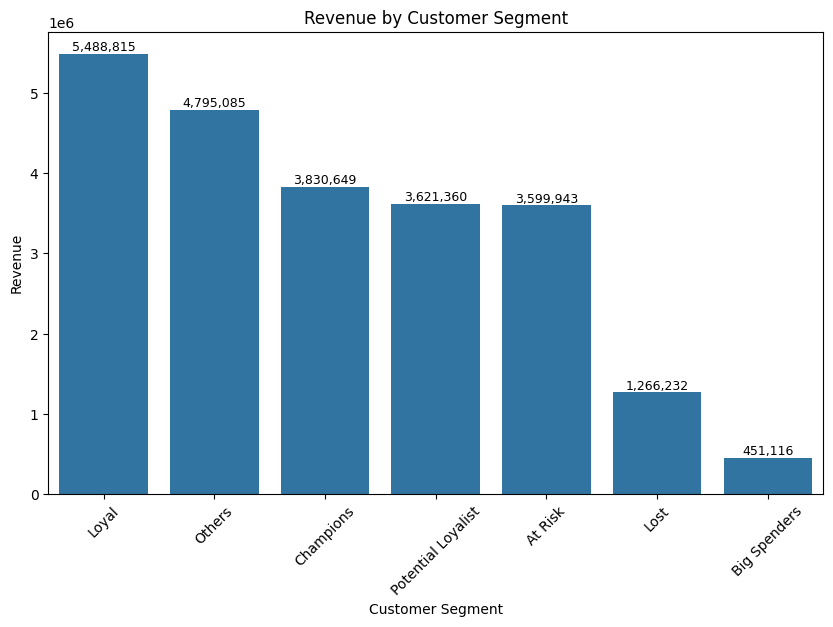

In [86]:
revenue_segment = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=revenue_segment.index,
    y=revenue_segment.values
)

for i, value in enumerate(revenue_segment.values):
    ax.text(
        i,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(rotation=45)
plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.show()

In [87]:
rfm.to_excel("RFM_Analysis.xlsx",index=False)

In [ ]:
# rfm.to_csv("RFM_Analysis.csv",index=False)

📌 Data Quality Insights
Data Quality Assessment

1) No missing values were detected in the customer and transaction datasets, indicating complete records for analysis.
2) Duplicate records were not found, ensuring data integrity.
3) Customer IDs were successfully validated, and all transactions were linked to valid customers.
4) Date columns were converted to the appropriate datetime format, enabling accurate Recency calculations.

📌 RFM Analysis Insights
RFM Customer Segmentation

1) Customers were successfully segmented based on Recency, Frequency, and Monetary (RFM) scores to identify different purchasing behaviors.
2) The Loyal Customer segment generated the highest revenue, indicating that repeat customers contribute significantly to overall business performance.
3) Champion customers represent the most valuable customer group due to their recent purchases, high purchase frequency, and high spending.
4) At Risk customers still contribute meaningful revenue despite declining engagement, making them a priority for customer retention campaigns.
5) Lost customers show low purchase frequency and low spending, suggesting limited future revenue unless re-engagement strategies are implemented.

📌 Revenue Insights
Revenue Analysis

1) Revenue is primarily generated by Loyal and Champion customers, emphasizing the importance of customer retention.
2) High-value customers significantly increase total revenue through larger purchase amounts.
3) Customer segmentation enables the business to prioritize marketing resources toward the most profitable customer groups.

📌 Business Recommendations
Recommendations

1) Develop loyalty programs and exclusive rewards to retain Champion and Loyal customers.
2) Launch personalized email or discount campaigns targeting At Risk customers to reduce churn.
3) Encourage Potential Loyalists to increase purchase frequency through targeted promotions.
4) Conduct periodic win-back campaigns for Lost customers using limited-time offers.
5) Continuously monitor customer purchasing behavior using RFM analysis to improve customer retention and maximize lifetime value.

📌 Executive Summary
Executive Summary

1) Customer behavior was successfully analyzed using the RFM framework to identify valuable customer segments.
2) Loyal customers represent the strongest revenue-driving segment and should remain the primary focus of retention efforts.
3) Champion customers demonstrate the highest customer value and should receive premium engagement strategies.
4) Data quality assessment confirmed clean and reliable data, with only 3.19% of transactions identified as high-value outliers that were retained for analysis.
5) Overall, the RFM model provides actionable insights that can support customer retention, personalized marketing campaigns, and long-term revenue growth